In [16]:
                                                             ##data cleaning 
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('data/Egypt_Houses_Price.csv')

# Remove leading/trailing whitespaces and unify 'Unknown' values
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Convert various 'Unknown' strings to actual NaN (Null) values
df.replace(['Unknown', 'Unknown ', 'Unknown Payment'], np.nan, inplace=True)

# Clean 'Type' column
type_mapping = {
    'Standalone Villa': 'Stand Alone Villa',
    'Twin house': 'Twin House',
    'Town House': 'Town House'
}
df['Type'] = df['Type'].replace(type_mapping)

# Clean and convert Numeric columns (Price, Bedrooms, Bathrooms, Area)
def clean_to_numeric(column):
    # Replace '10+' with 10 and convert to numeric, making errors NaN
    return pd.to_numeric(column.astype(str).str.replace('10+', '10'), errors='coerce')

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Bedrooms'] = clean_to_numeric(df['Bedrooms'])
df['Bathrooms'] = clean_to_numeric(df['Bathrooms'])
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

# Clean 'Level' column
level_mapping = {
    'Ground': 0,
    '10+': 10,
    'Highest': 11 
}
df['Level'] = df['Level'].replace(level_mapping)
df['Level'] = pd.to_numeric(df['Level'], errors='coerce')


# Handle Missing Values
# Drop rows where 'Price' is missing 
df.dropna(subset=['Price'], inplace=True)

# Save the cleaned data
df.to_csv('Egypt_Houses_Cleaned.csv', index=False)

print(f"Total records remaining: {len(df)}")
print("\n--- Cleaned Data Head ---")
print(df.head())

# Display data types to verify conversions
print("\n--- Column Data Types ---")
print(df.dtypes)

Total records remaining: 27322

--- Cleaned Data Head ---
        Type      Price  Bedrooms  Bathrooms   Area Furnished  Level Compound  \
0     Duplex  4000000.0       3.0        3.0  400.0        No    7.0      NaN   
1  Apartment  4000000.0       3.0        3.0  160.0        No   10.0      NaN   
2  Apartment  2250000.0       3.0        2.0  165.0        No    1.0      NaN   
3  Apartment  1900000.0       3.0        2.0  230.0        No   10.0      NaN   
4  Apartment  5800000.0       2.0        3.0  160.0        No    0.0  Eastown   

  Payment_Option  Delivery_Date  Delivery_Term                    City  
0           Cash  Ready to move       Finished               Nasr City  
1           Cash  Ready to move       Finished             Camp Caesar  
2           Cash  Ready to move       Finished                   Smoha  
3           Cash  Ready to move       Finished               Nasr City  
4           Cash  Ready to move  Semi Finished  New Cairo - El Tagamoa  

--- Column Data 

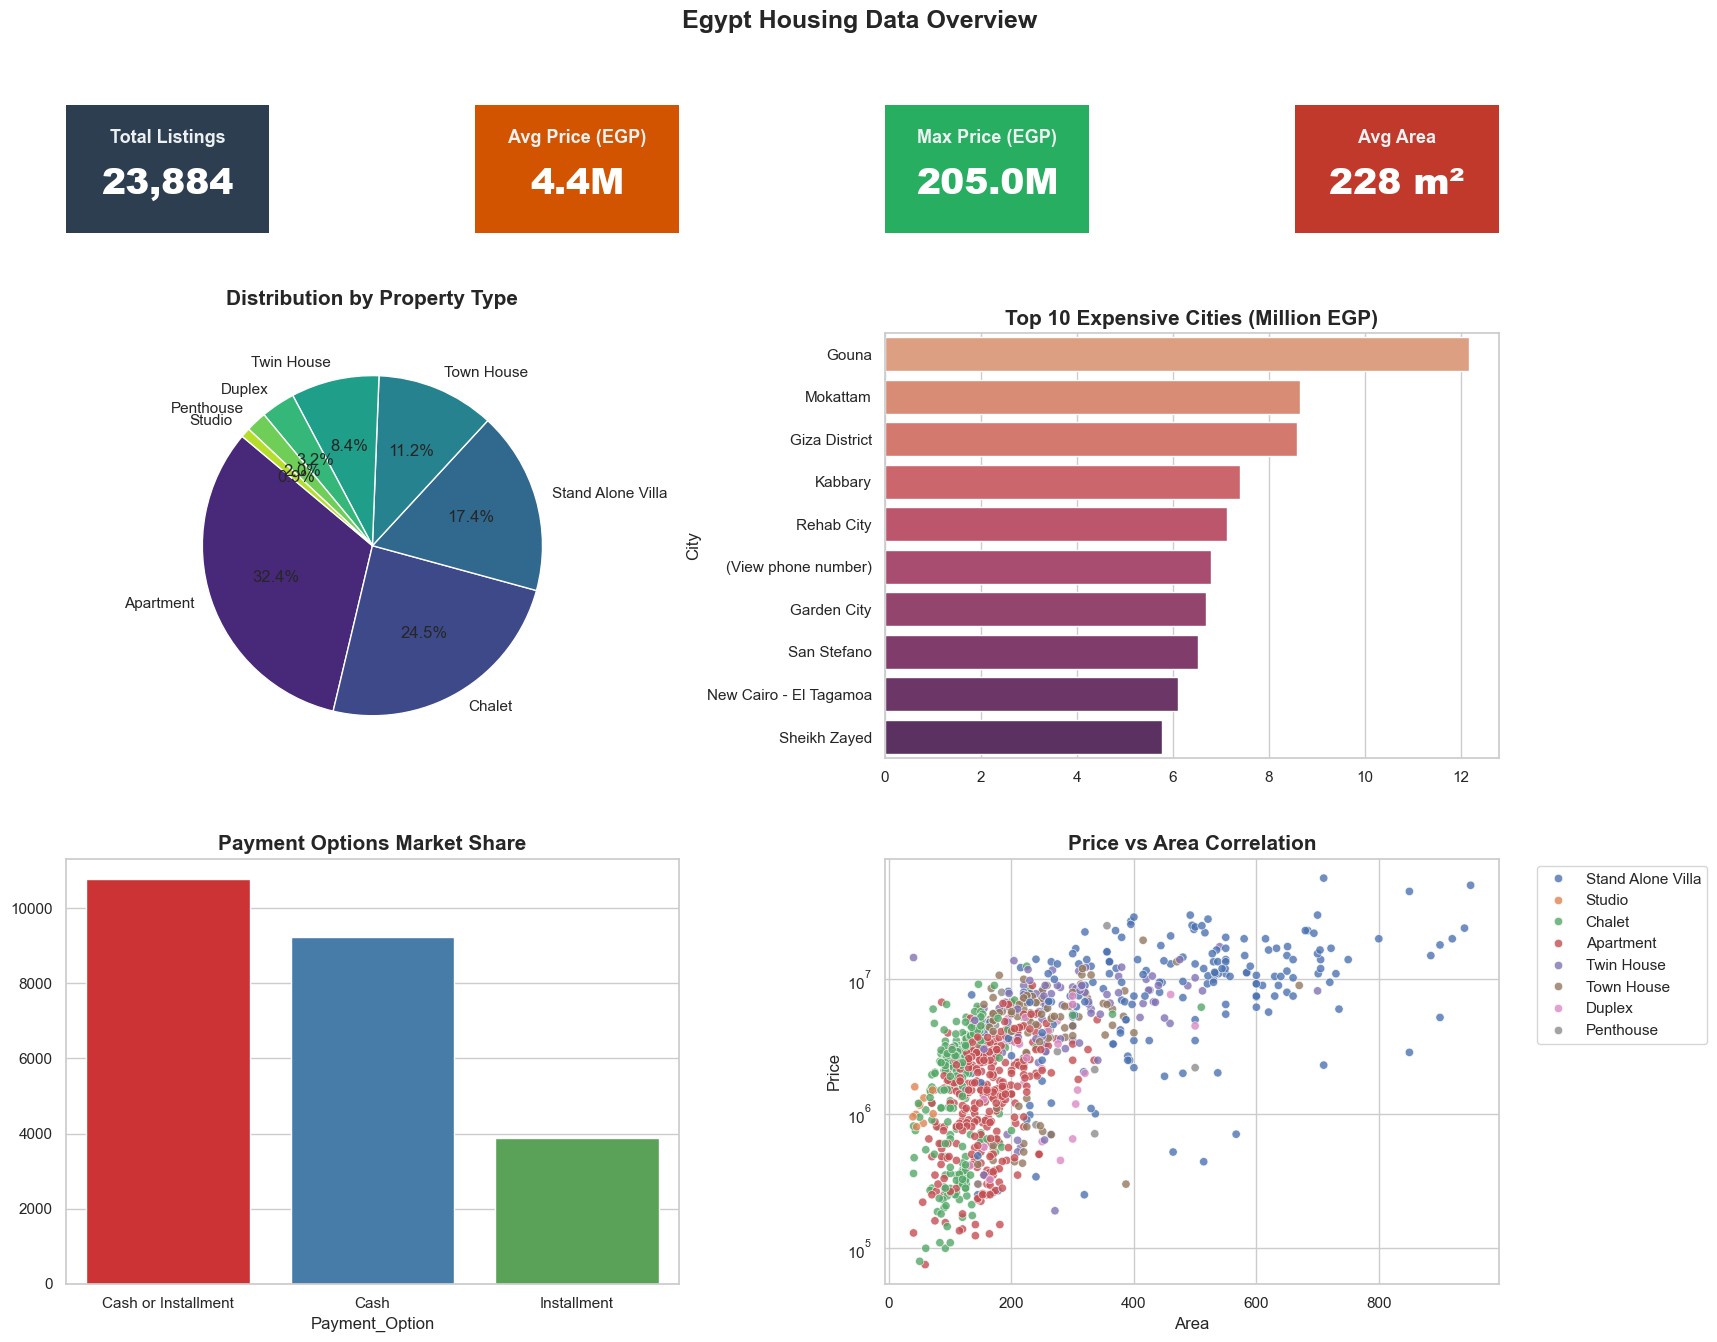

In [29]:
                                                                ##data overview
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/Egypt_Houses_Cleaned.csv")

# Style
sns.set_theme(style="whitegrid")

# Clean data
df = df.dropna(subset=["Type", "Price", "Area", "City", "Payment_Option"])
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df = df.dropna(subset=["Price"])

# --- Calculations ---
total_listings = len(df)
avg_price = df["Price"].mean()
max_price = df["Price"].max()
avg_area = df["Area"].mean()

# Create figure
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 4, height_ratios=[0.6, 2, 2])

# title name 
plt.suptitle("Egypt Housing Data Overview", fontsize=18, fontweight='bold')
# Top Cards Section

card_colors = ['#2C3E50', '#D35400', '#27AE60', '#C0392B']
text_main_color = '#FFFFFF' 
text_label_color = '#ECF0F1' 

cards_data = [
    ("Total Listings", f"{total_listings:,}"),
    ("Avg Price (EGP)", f"{avg_price/1e6:.1f}M"),
    ("Max Price (EGP)", f"{max_price/1e6:.1f}M"),
    ("Avg Area", f"{avg_area:.0f} m²")
]

for i, (label, value) in enumerate(cards_data):
    ax_card = fig.add_subplot(gs[0, i])
    ax_card.set_facecolor(card_colors[i])
    
    
    ax_card.text(0.5, 0.7, label, fontsize=13, ha='center', fontweight='bold', color=text_label_color)
   
    ax_card.text(0.5, 0.3, value, fontsize=26, ha='center', fontweight='extra bold', color=text_main_color)
    
    ax_card.set_xticks([])
    ax_card.set_yticks([])
    for spine in ax_card.spines.values():
        spine.set_visible(False)


# Pie Chart
ax1 = fig.add_subplot(gs[1, 0:2])
type_counts = df["Type"].value_counts()
ax1.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis", len(type_counts)))
ax1.set_title("Distribution by Property Type", fontsize=15, fontweight='bold', pad=20)

# Top 10 Expensive Cities
ax2 = fig.add_subplot(gs[1, 2:4])
top_cities = (df.groupby("City")["Price"].mean().sort_values(ascending=False).head(10) / 1_000_000)
sns.barplot(x=top_cities.values, y=top_cities.index, hue=top_cities.index, palette="flare", legend=False, ax=ax2)
ax2.set_title("Top 10 Expensive Cities (Million EGP)", fontsize=15, fontweight='bold')

# Payment Options
ax3 = fig.add_subplot(gs[2, 0:2])
payment_counts = df["Payment_Option"].value_counts()
sns.barplot(x=payment_counts.index, y=payment_counts.values, hue=payment_counts.index, palette="Set1", legend=False, ax=ax3)
ax3.set_title("Payment Options Market Share", fontsize=15, fontweight='bold')

# Scatter Plot
ax4 = fig.add_subplot(gs[2, 2:4])
sns.scatterplot(data=df.sample(min(1000, len(df))), x="Area", y="Price", hue="Type", alpha=0.8, palette="deep", ax=ax4)
ax4.set_yscale("log")
ax4.set_title("Price vs Area Correlation", fontsize=15, fontweight='bold')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(pad=3.0)
plt.show()

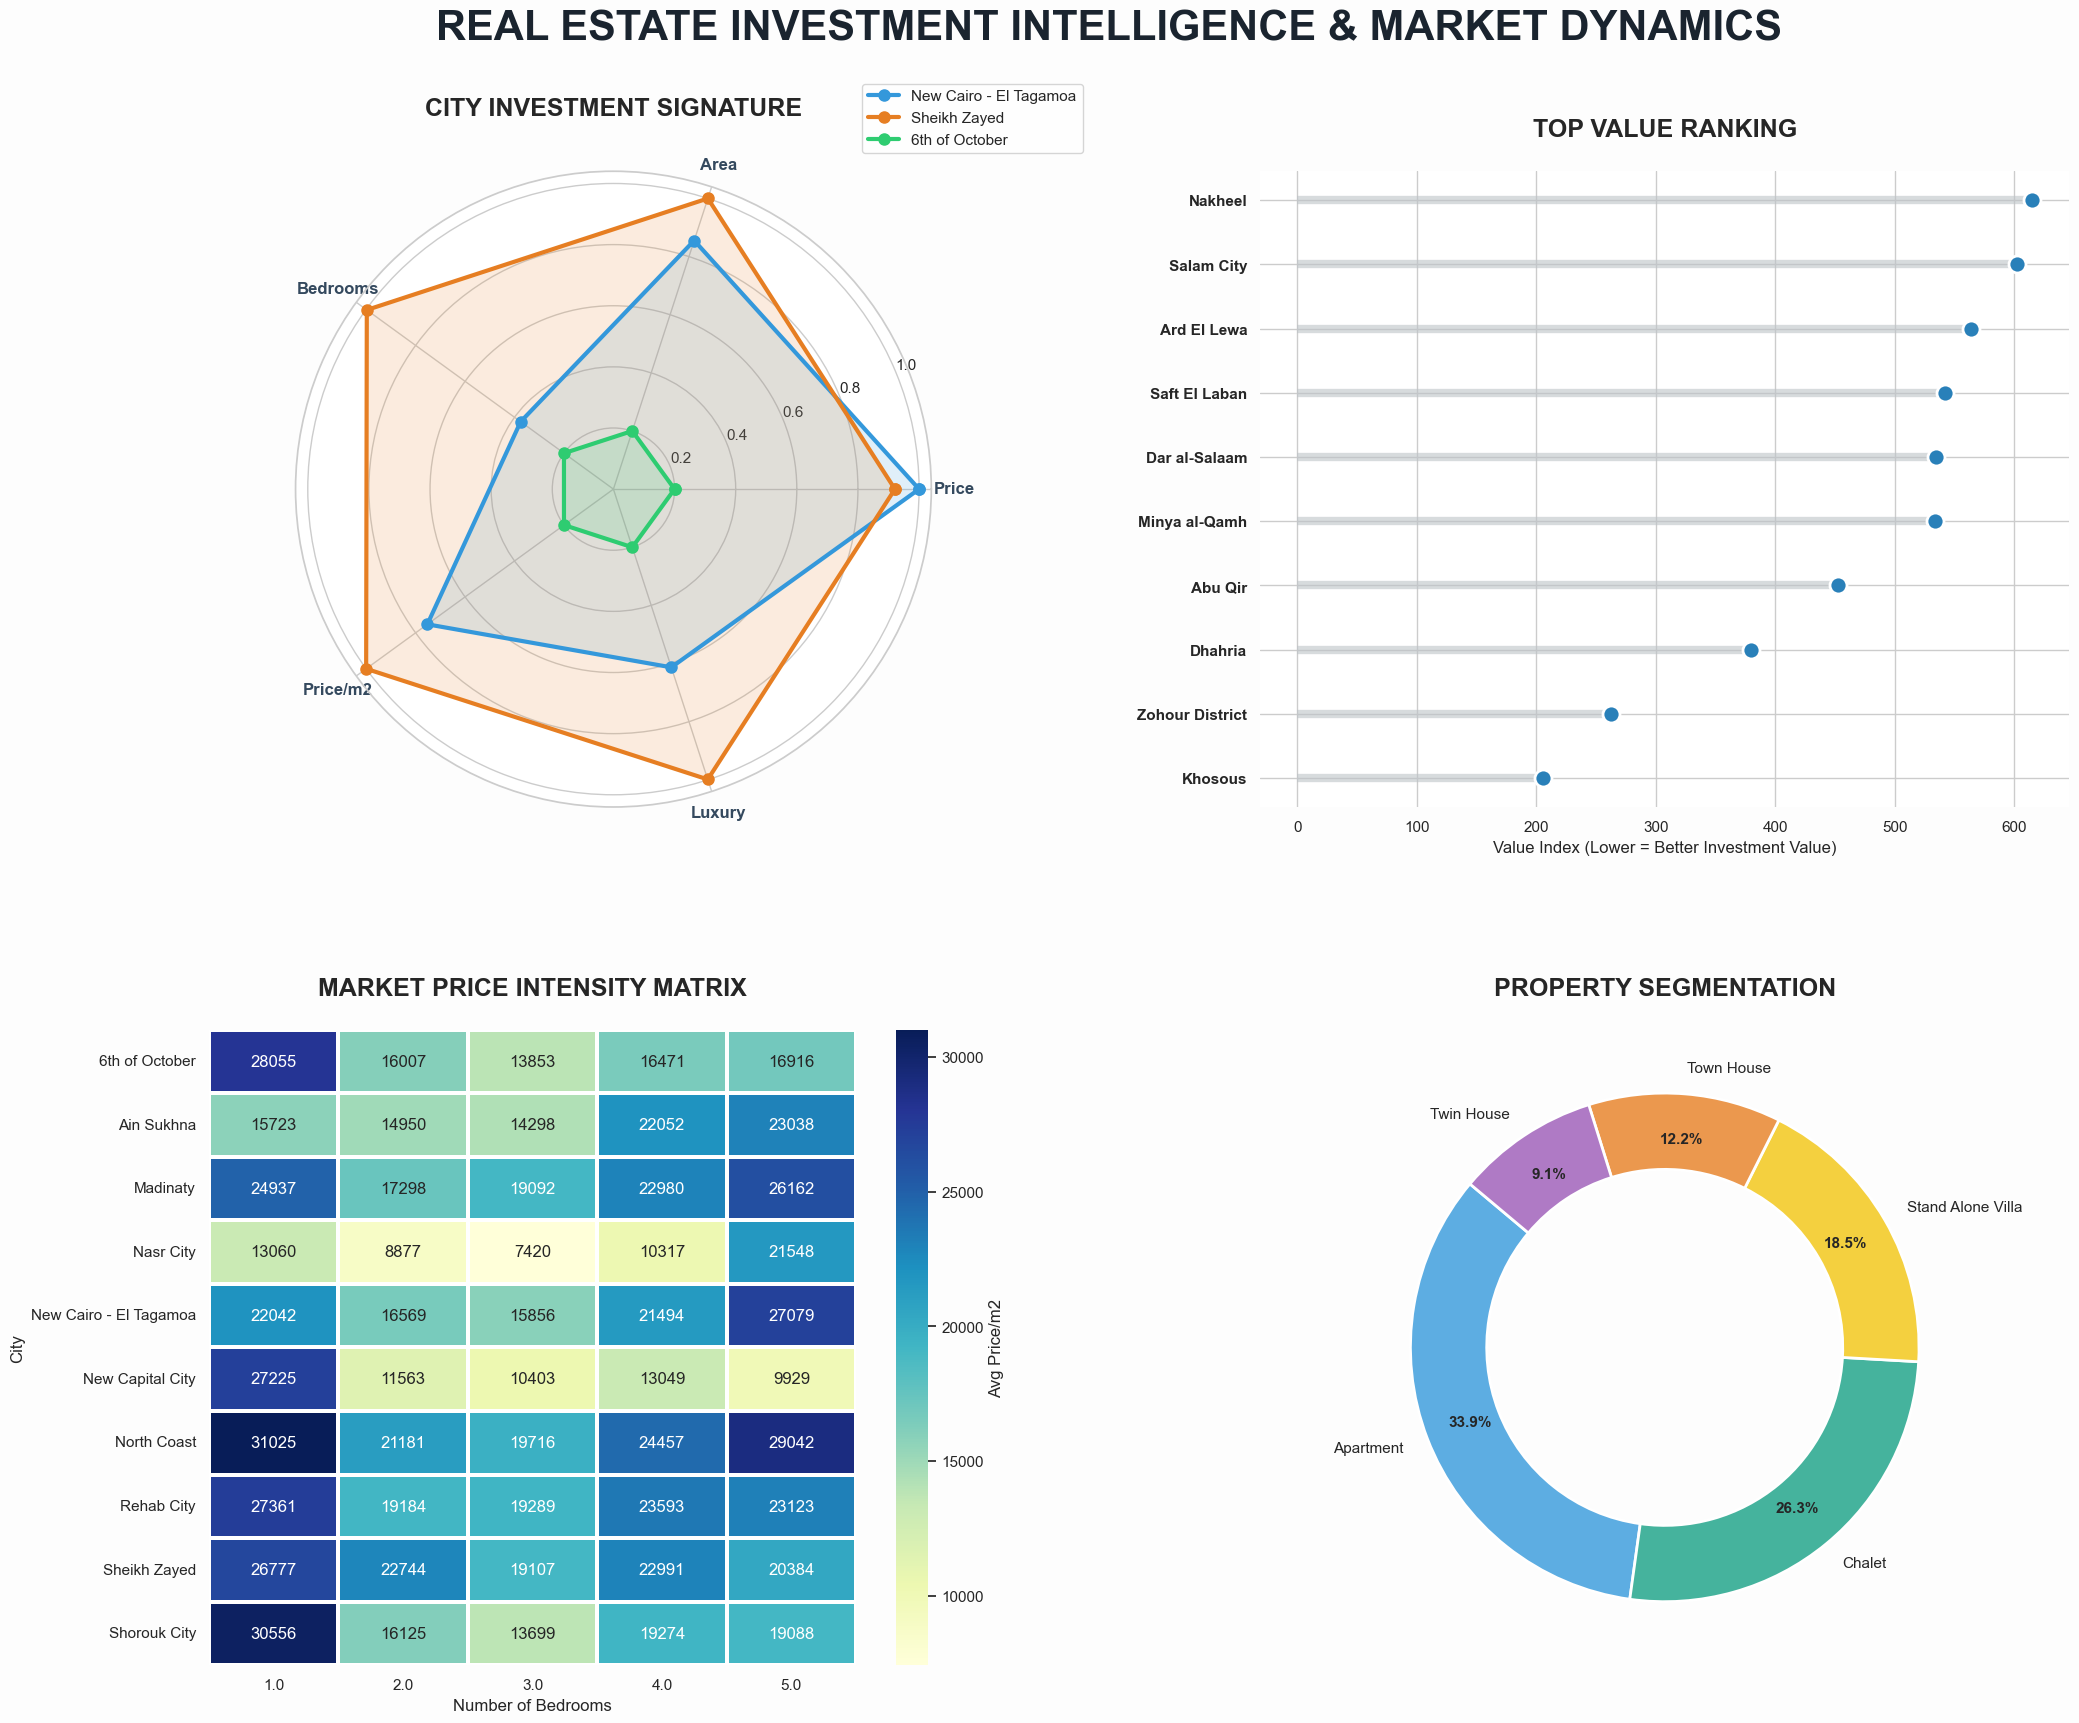

In [30]:
                                                   ##REAL ESTATE INTELLIGENCE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

# Data Loading and Preprocessing
df = pd.read_csv("data/Egypt_Houses_Cleaned.csv")
df = df.dropna(subset=["Price", "Area", "City", "Type", "Bedrooms", "Bathrooms"])
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")
df = df[(df['Price'] > 0) & (df['Area'] > 0)]

# Calculate price per square meter
df['Price_per_m2'] = df['Price'] / df['Area']
# Luxury score combines bedrooms and bathrooms
df['Luxury_Score'] = df['Bedrooms'] + df['Bathrooms']
# Investment Value Index: Lower values indicate higher asset value for price
df['Investment_Value'] = df['Price_per_m2'] / (df['Luxury_Score'] + 1)

# Prepare data for Radar Chart (Top 3 Comparison)
target_cities = ["New Cairo - El Tagamoa", "Sheikh Zayed", "6th of October"]
radar_df = df[df['City'].isin(target_cities)].groupby('City').agg({
    'Price': 'mean', 'Area': 'mean', 'Bedrooms': 'mean', 
    'Price_per_m2': 'mean', 'Luxury_Score': 'mean'
}).reset_index()

# Normalize radar 
for col in radar_df.columns[1:]:
    col_min = radar_df[col].min()
    col_max = radar_df[col].max()
    radar_df[col] = 0.2 + (radar_df[col] - col_min) / (col_max - col_min + 0.001) * 0.8

# Dashboard Configuration
fig = plt.figure(figsize=(24, 18), facecolor='#FDFDFD')
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# Main Title
fig.suptitle('REAL ESTATE INVESTMENT INTELLIGENCE & MARKET DYNAMICS', 
             fontsize=30, fontweight='bold', color='#1A242F', y=0.97)

# Investment Profile 
# Compares different investment dimensions for top-tier cities
ax1 = fig.add_subplot(gs[0, 0], polar=True)
categories = ['Price', 'Area', 'Bedrooms', 'Price/m2', 'Luxury']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

city_colors = ['#3498DB', '#E67E22', '#2ECC71']
for i, city in enumerate(target_cities):
    # Fetch values for each specific city
    values = radar_df[radar_df['City'] == city].iloc[0, 1:].tolist()
    values += values[:1]
    ax1.plot(angles, values, linewidth=3, label=city, color=city_colors[i], marker='o', markersize=8)
    ax1.fill(angles, values, color=city_colors[i], alpha=0.15)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, fontsize=12, fontweight='bold', color='#34495E')
ax1.set_title("CITY INVESTMENT SIGNATURE", size=18, fontweight='bold', pad=40)
ax1.legend(loc='upper right', bbox_to_anchor=(1.25, 1.15))

# Best Value Ranking 
ax2 = fig.add_subplot(gs[0, 1])
top_cities_val = df.groupby('City')['Investment_Value'].mean().sort_values().head(10)
y_range = range(1, len(top_cities_val.index) + 1)
ax2.hlines(y=y_range, xmin=0, xmax=top_cities_val.values, color='#BDC3C7', alpha=0.6, linewidth=6)
ax2.scatter(top_cities_val.values, y_range, color='#2980B9', s=150, zorder=3, edgecolors='white', linewidth=2)
ax2.set_yticks(y_range); ax2.set_yticklabels(top_cities_val.index, fontweight='bold', fontsize=11)
ax2.set_title("TOP VALUE RANKING", size=18, fontweight='bold', pad=25)
ax2.set_xlabel("Value Index (Lower = Better Investment Value)")
sns.despine(ax=ax2, left=True, bottom=True)

# Pricing Heatmap Matrix
ax3 = fig.add_subplot(gs[1, 0])
bedroom_filter = [1, 2, 3, 4, 5]
top_10_cities = df['City'].value_counts().head(10).index
pivot_data = df[(df['Bedrooms'].isin(bedroom_filter)) & (df['City'].isin(top_10_cities))].pivot_table(
    index='City', columns='Bedrooms', values='Price_per_m2', aggfunc='mean'
)
sns.heatmap(pivot_data, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax3, linewidths=1.5, cbar_kws={'label': 'Avg Price/m2'})
ax3.set_title("MARKET PRICE INTENSITY MATRIX", size=18, fontweight='bold', pad=25)
ax3.set_xlabel("Number of Bedrooms")

# Property Composition 
ax4 = fig.add_subplot(gs[1, 1])
type_counts = df['Type'].value_counts().head(5)
colors = ['#5DADE2', '#45B39D', '#F4D03F', '#EB984E', '#AF7AC5']
wedges, texts, autotexts = ax4.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
                                  startangle=140, pctdistance=0.82, colors=colors, 
                                  wedgeprops=dict(width=0.3, edgecolor='w', linewidth=2))
plt.setp(autotexts, size=11, weight="bold")
ax4.set_title("PROPERTY SEGMENTATION", size=18, fontweight='bold', pad=25)

plt.subplots_adjust(top=0.88, bottom=0.05, hspace=0.3)
plt.show()

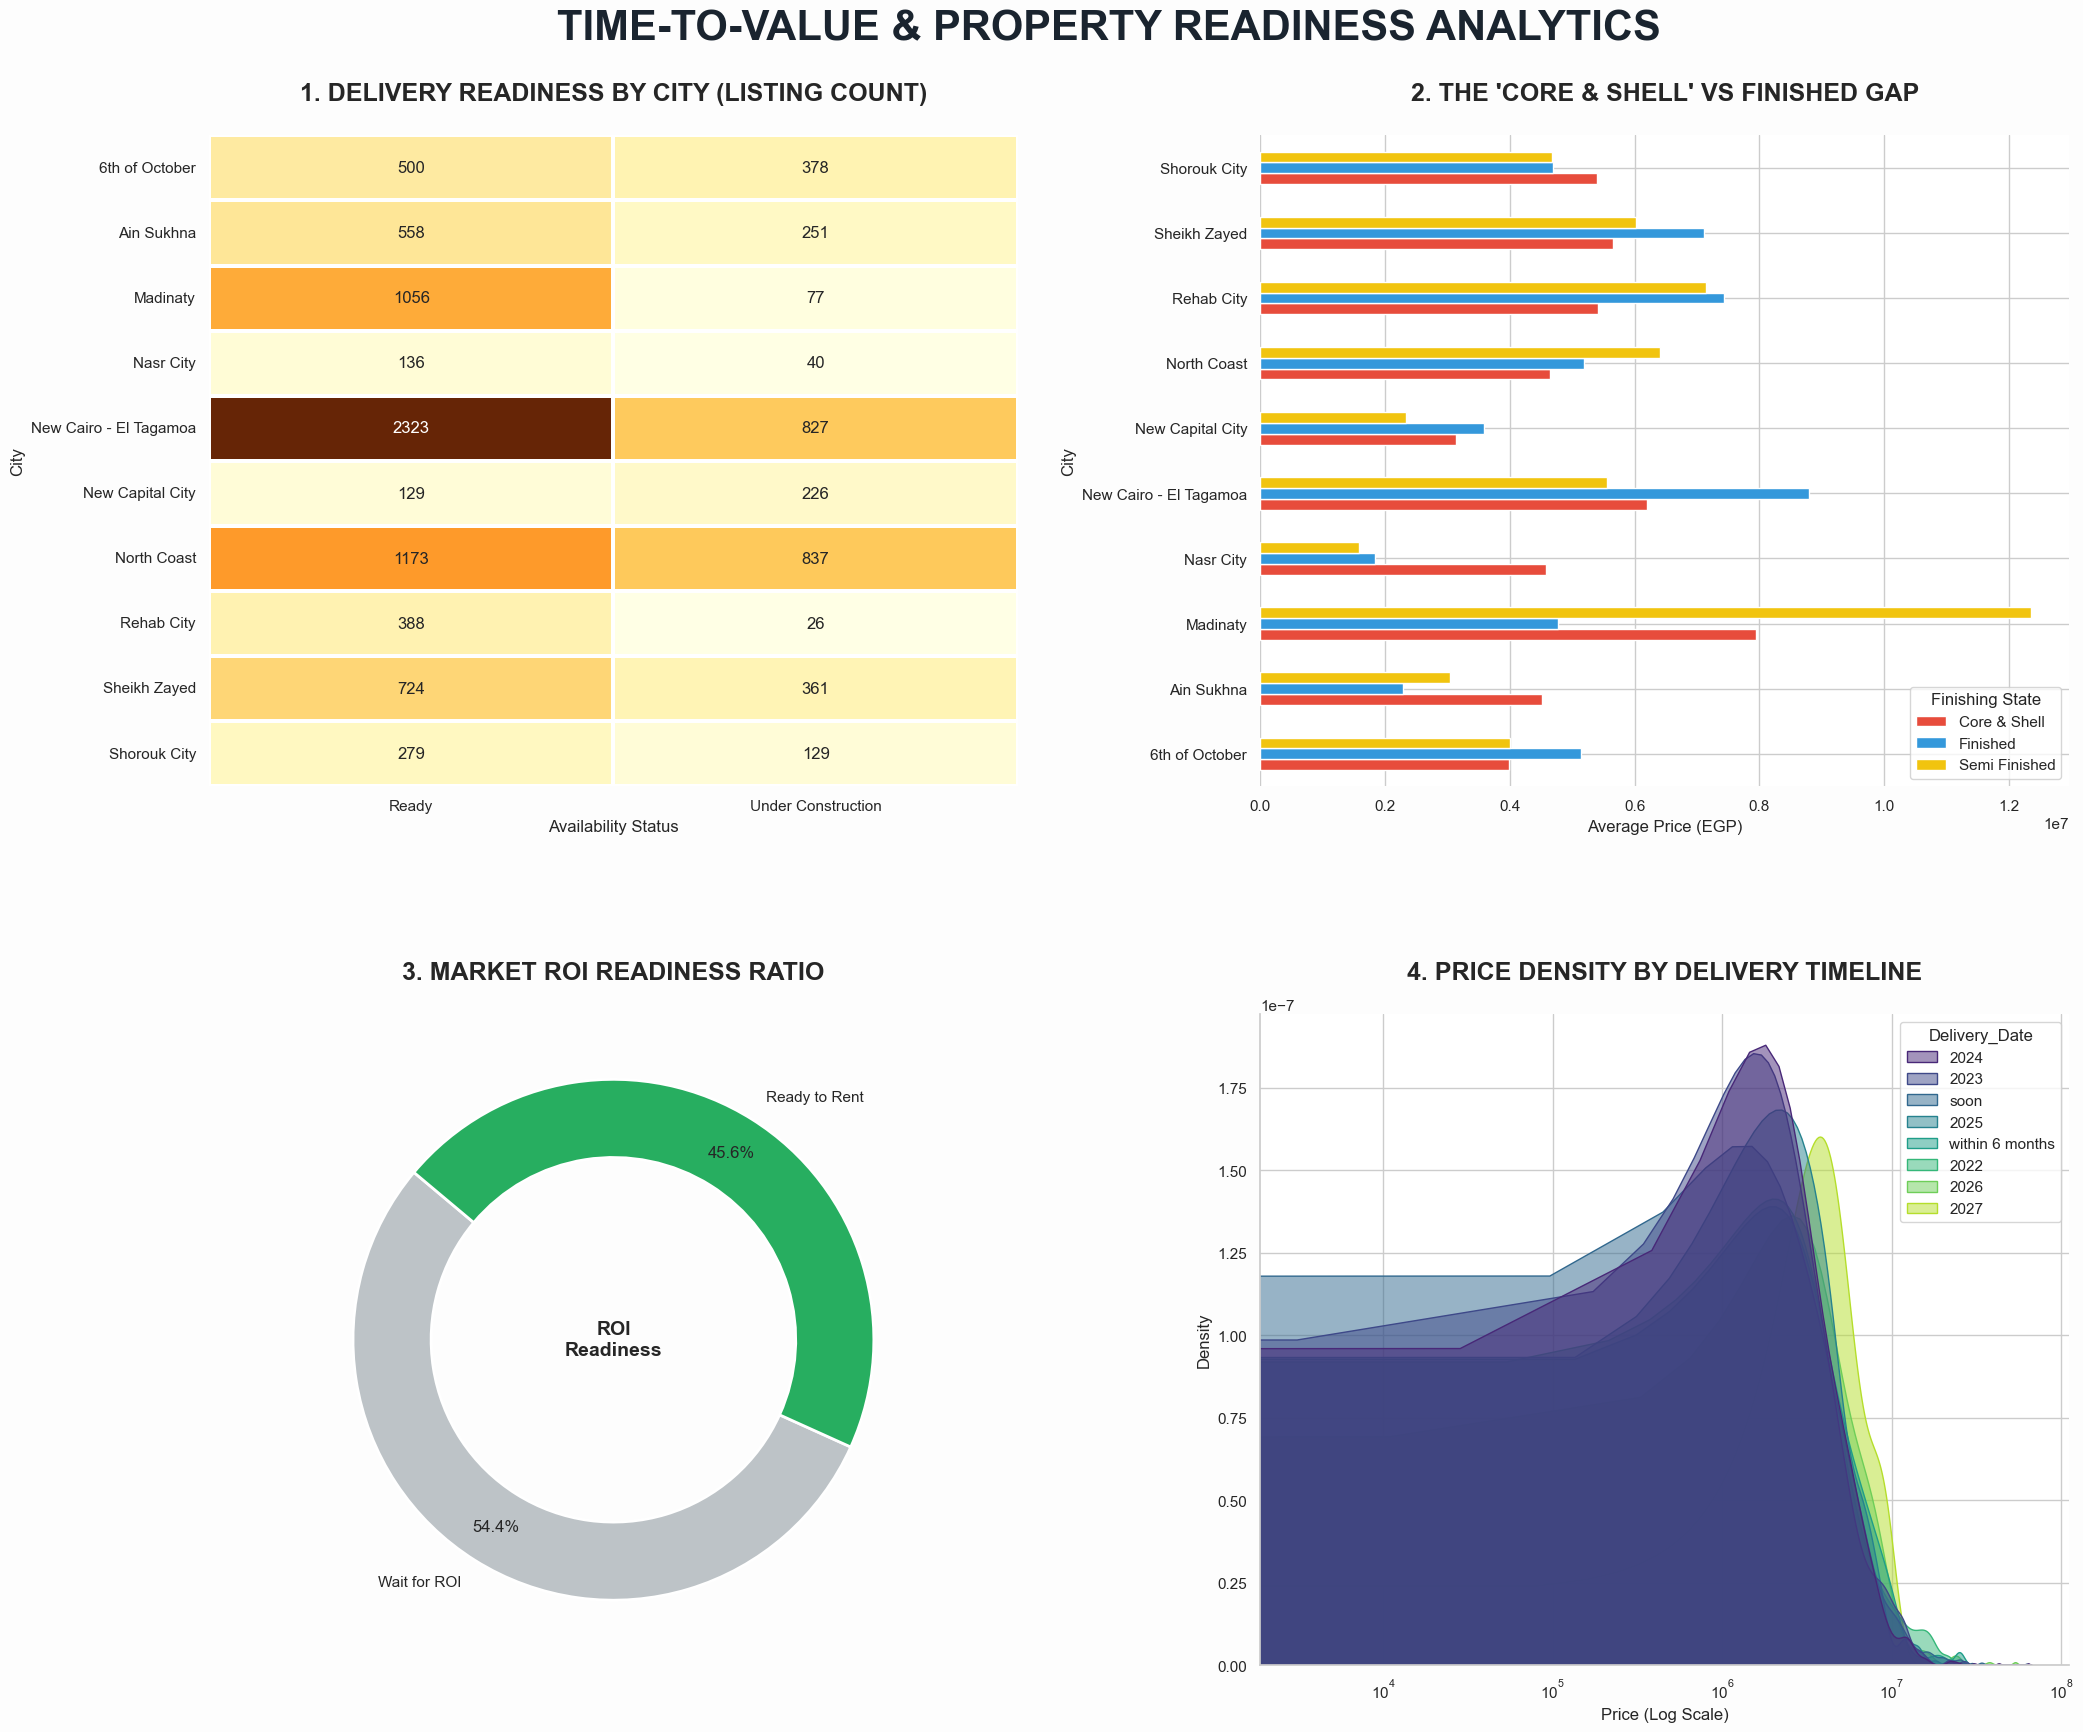

In [31]:
                                                      ##PROPERTY READINESS ANALYTICS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Loading and Preprocessing
df = pd.read_csv("data/Egypt_Houses_Cleaned.csv")
df = df.dropna(subset=["Price", "Area", "City", "Delivery_Date", "Delivery_Term", "Furnished"])
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df = df[df['Price'] > 0]

# Logic and Metrics Calculation
# Define Readiness: Ready to Move vs Under Construction
df['Readiness'] = df['Delivery_Date'].apply(lambda x: 'Ready' if 'Ready' in str(x) else 'Under Construction')

# Define Rent-Ready Units: (Ready to move AND Finished/Furnished)
df['Rent_Ready'] = (df['Readiness'] == 'Ready') & (df['Delivery_Term'] == 'Finished')

# Average Price for Core & Shell vs Finished
top_10_cities = df['City'].value_counts().head(10).index
df_gap = df[df['City'].isin(top_10_cities)]

# Dashboard Configuration & Aesthetics
fig = plt.figure(figsize=(24, 18), facecolor='#FDFDFD')
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

#  Main Title
fig.suptitle('TIME-TO-VALUE & PROPERTY READINESS ANALYTICS', 
             fontsize=30, fontweight='bold', color='#1A242F', y=0.97)

#  Delivery Status Heatmap
# Shows concentration of ready vs. future units across top cities
ax1 = fig.add_subplot(gs[0, 0])
pivot_readiness = df[df['City'].isin(top_10_cities)].pivot_table(
    index='City', columns='Readiness', values='Price', aggfunc='count', fill_value=0
)
sns.heatmap(pivot_readiness, annot=True, fmt="d", cmap="YlOrBr", ax=ax1, linewidths=1.5, cbar=False)
ax1.set_title("1. DELIVERY READINESS BY CITY (LISTING COUNT)", size=18, fontweight='bold', pad=25)
ax1.set_xlabel("Availability Status")

# The Core & Shell Price Gap
# Visualizes the cost difference between raw and finished units
ax2 = fig.add_subplot(gs[0, 1])
gap_data = df_gap[df_gap['Delivery_Term'].isin(['Finished', 'Core & Shell', 'Semi Finished'])].groupby(['City', 'Delivery_Term'])['Price'].mean().unstack()
gap_data.plot(kind='barh', stacked=False, ax=ax2, color=['#E74C3C', '#3498DB', '#F1C40F'], edgecolor='white', linewidth=1)
ax2.set_title("2. THE 'CORE & SHELL' VS FINISHED GAP", size=18, fontweight='bold', pad=25)
ax2.set_xlabel("Average Price (EGP)")
ax2.legend(title="Finishing State", loc='lower right')
sns.despine(ax=ax2, left=True, bottom=True)

# Ready-to-Rent Ratio 
# Analyzes how many units are actually ready for immediate ROI
ax3 = fig.add_subplot(gs[1, 0])
ready_rent_counts = df['Rent_Ready'].value_counts()
colors_rent = ['#BDC3C7', '#27AE60'] # Grey for no, Green for yes
ax3.pie(ready_rent_counts, labels=['Wait for ROI', 'Ready to Rent'], autopct='%1.1f%%', 
        startangle=140, pctdistance=0.85, colors=colors_rent, 
        wedgeprops=dict(width=0.3, edgecolor='w', linewidth=2))

ax3.text(0, 0, 'ROI\nReadiness', ha='center', va='center', fontsize=14, fontweight='bold')
ax3.set_title("3. MARKET ROI READINESS RATIO", size=18, fontweight='bold', pad=25)

# Future Delivery Countdown
# Shows the distribution of prices over delivery timelines
ax4 = fig.add_subplot(gs[1, 1])
# Filter out "Ready to move" for the timeline plot to focus on future dates
future_df = df[df['Readiness'] == 'Under Construction']
sns.kdeplot(data=future_df, x="Price", hue="Delivery_Date", fill=True, common_norm=False, palette="viridis", alpha=0.5, ax=ax4)
ax4.set_xscale("log")
ax4.set_title("4. PRICE DENSITY BY DELIVERY TIMELINE", size=18, fontweight='bold', pad=25)
ax4.set_xlabel("Price (Log Scale)")
sns.despine(ax=ax4)

plt.subplots_adjust(top=0.90, bottom=0.05, hspace=0.3)
plt.show()

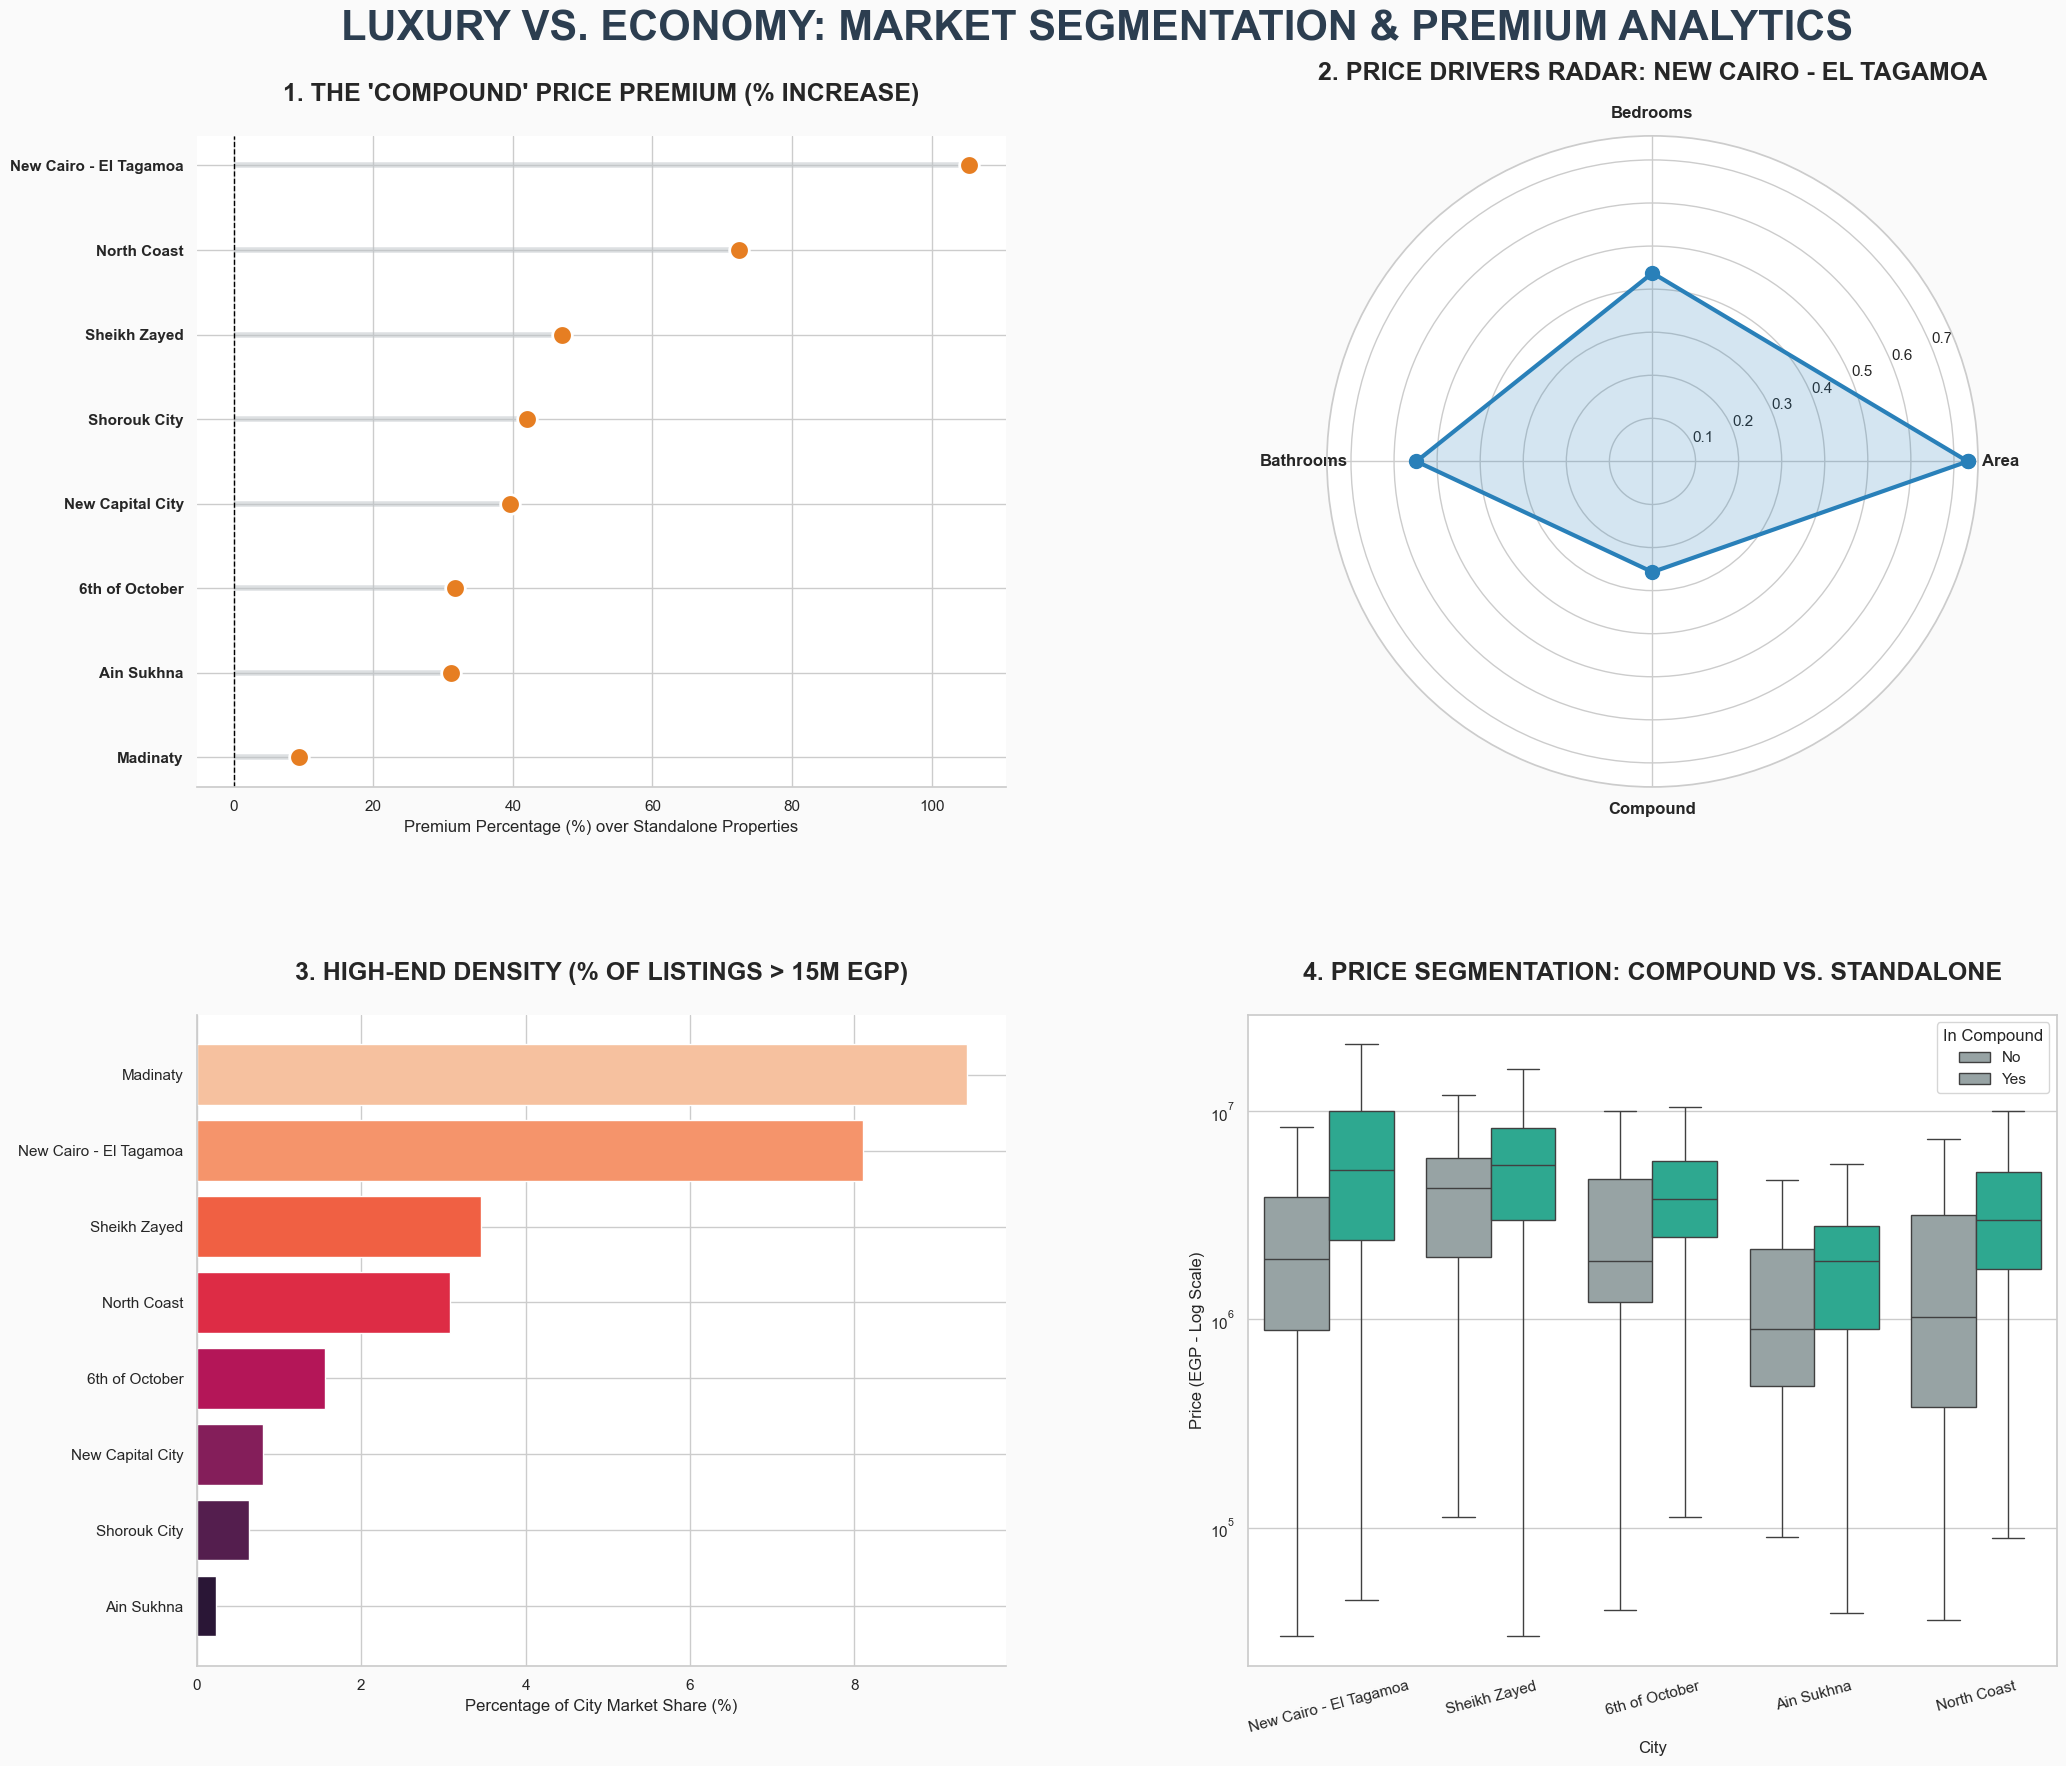

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

# Data Loading and Cleaning
df = pd.read_csv("data/Egypt_Houses_Cleaned.csv")
# Essential columns for segmentation
cols = ["Price", "Area", "City", "Type", "Bedrooms", "Bathrooms", "Compound"]
df = df.dropna(subset=["Price", "Area", "City"])
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")
df["Bedrooms"] = pd.to_numeric(df["Bedrooms"], errors="coerce").fillna(0)
df["Bathrooms"] = pd.to_numeric(df["Bathrooms"], errors="coerce").fillna(0)
df = df[df['Price'] > 0]
 
# Check if the property is inside a Compound
df['In_Compound'] = df['Compound'].apply(lambda x: 1 if pd.notna(x) and str(x).strip() != "" else 0)
# Define Luxury segment (properties above 15 Million EGP)
df['Segment'] = df['Price'].apply(lambda x: 'Luxury' if x > 15_000_000 else 'Economy/Mid')

# Compound Premium % calculation
top_cities = df['City'].value_counts().head(8).index
premium_data = []
for city in top_cities:
    city_df = df[df['City'] == city]
    avg_compound = city_df[city_df['In_Compound'] == 1]['Price'].mean()
    avg_standalone = city_df[city_df['In_Compound'] == 0]['Price'].mean()
    if avg_standalone > 0 and not np.isnan(avg_compound):
        perc_premium = ((avg_compound - avg_standalone) / avg_standalone) * 100
        premium_data.append({'City': city, 'Premium_Pct': perc_premium})
premium_df = pd.DataFrame(premium_data).sort_values('Premium_Pct')

# Price Drivers Correlation Case Study
target_city = "New Cairo - El Tagamoa"
city_corr = df[df['City'] == target_city][['Price', 'Area', 'Bedrooms', 'Bathrooms', 'In_Compound']].corr()['Price'].drop('Price')
radar_values = city_corr.tolist()
radar_labels = ['Area', 'Bedrooms', 'Bathrooms', 'Compound']
radar_values += radar_values[:1] 

# High-End Density Share
luxury_density = df[df['City'].isin(top_cities)].groupby('City')['Segment'].value_counts(normalize=True).unstack().fillna(0)
luxury_density = luxury_density['Luxury'] * 100

# Dashboard Setup
fig = plt.figure(figsize=(24, 18), facecolor='#FAFAFA')
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

fig.suptitle('LUXURY VS. ECONOMY: MARKET SEGMENTATION & PREMIUM ANALYTICS', 
             fontsize=30, fontweight='bold', color='#2C3E50', y=0.97)

#  Compound Price Premium 
# Shows the % increase in price when living in a compound vs outside
ax1 = fig.add_subplot(gs[0, 0])
y_range = range(len(premium_df))
ax1.hlines(y=y_range, xmin=0, xmax=premium_df['Premium_Pct'], color='#BDC3C7', alpha=0.5, linewidth=4)
ax1.scatter(premium_df['Premium_Pct'], y_range, color='#E67E22', s=200, edgecolor='w', linewidth=2, zorder=3)
ax1.set_yticks(y_range); ax1.set_yticklabels(premium_df['City'], fontweight='bold', fontsize=11)
ax1.set_title("1. THE 'COMPOUND' PRICE PREMIUM (% INCREASE)", size=18, fontweight='bold', pad=25)
ax1.set_xlabel("Premium Percentage (%) over Standalone Properties")
ax1.axvline(0, color='black', lw=1, ls='--')
sns.despine(ax=ax1, left=True)

#  Price Drivers Radar
# Analyzes which feature correlates most with price in the most luxury-dense city
ax2 = fig.add_subplot(gs[0, 1], polar=True)
angles = [n / float(len(radar_labels)) * 2 * pi for n in range(len(radar_labels))]
angles += angles[:1]
ax2.plot(angles, radar_values, color='#2980B9', linewidth=3, marker='o', markersize=10)
ax2.fill(angles, radar_values, color='#2980B9', alpha=0.2)
ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(radar_labels, fontsize=12, fontweight='bold')
ax2.set_title(f"2. PRICE DRIVERS RADAR: {target_city.upper()}", size=18, fontweight='bold', pad=40)
 
# Shows the percentage of properties that fall into the luxury segment (>15M EGP)
ax3 = fig.add_subplot(gs[1, 0])
luxury_density = luxury_density.sort_values()
ax3.barh(luxury_density.index, luxury_density.values, color=sns.color_palette("rocket", len(luxury_density)), edgecolor='w')
ax3.set_title("3. HIGH-END DENSITY (% OF LISTINGS > 15M EGP)", size=18, fontweight='bold', pad=25)
ax3.set_xlabel("Percentage of City Market Share (%)")
sns.despine(ax=ax3)

# Compares price spread for Compound vs Standalone across major cities
ax4 = fig.add_subplot(gs[1, 1])
top_5_cities = df['City'].value_counts().head(5).index
sns.boxplot(data=df[df['City'].isin(top_5_cities)], x='City', y='Price', hue='In_Compound', 
            palette={1: '#1ABC9C', 0: '#95A5A6'}, ax=ax4, showfliers=False)
ax4.set_title("4. PRICE SEGMENTATION: COMPOUND VS. STANDALONE", size=18, fontweight='bold', pad=25)
ax4.set_yscale('log'); ax4.set_ylabel("Price (EGP - Log Scale)")
ax4.legend(title="In Compound", labels=['No', 'Yes'])
plt.xticks(rotation=15)

plt.subplots_adjust(top=0.90, bottom=0.05, hspace=0.3)
plt.show()